In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.stats import loguniform, randint

In [2]:
df = pd.read_csv("Data_UVA_SNAProject.csv")
df = df.drop(columns = ['new_err'])

In [3]:
y = df['error_target']

leakage   = ['Error', 'main_error_type', 'Type', 'Classification']
ids       = ['new_case_num', 'new_emp_num']
date_cols = ['mdate']

X = df.drop(columns=['error_target'] + leakage + ids + date_cols)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=441, stratify = y)

In [4]:
string_cats  = ['va_region', 'job_category']
encoded_cats = ['group_region', 'grouprace', 'max_educ']
binary_cats  = ['flag_monoeth', 'flag_monolang', 'case_english', 'case_nonenglish',
                'self_empl', 'is_children', 'is_disable', 'is_old', 'is_married',
                'is_separated', 'move_flag', 'aboveavg_uern_fips', 'aboveavg_ern_fips',
                'aboveavg_shl_fips', 'round_income', 'round_income_un', 'flag_inchh']

categorical = string_cats + encoded_cats + binary_cats

missing = set(categorical) - set(X.columns)
assert not missing, f"Not in X: {missing}"

param_distributions = {
    'learning_rate': loguniform(0.005, 0.3), 
    'max_leaf_nodes': randint(10, 80),
    'min_samples_leaf': randint(20, 150),
}

model = HistGradientBoostingClassifier(
    categorical_features = categorical,
    early_stopping = True,
    validation_fraction = 0.1,
    n_iter_no_change = 20,
    max_iter = 1000,
    random_state = 441
)

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='roc_auc',              
    cv=5,
    random_state=42,
    n_jobs=-1,
    refit=True,
)

err_train = df.loc[X_train.index, 'Error']

w_train = 1 + np.log1p(err_train)

assert np.allclose(w_train[y_train == 0], 1.0)

In [5]:
search.fit(X_train, y_train, sample_weight = w_train)
best_model = search.best_estimator_
print(search.best_params_, search.best_score_)

{'learning_rate': np.float64(0.01275873885428681), 'max_leaf_nodes': 41, 'min_samples_leaf': 90} 0.7464454514060268


Best params: {'learning_rate': np.float64(0.01275873885428681), 'max_leaf_nodes': 41, 'min_samples_leaf': 90}
Best CV ROC AUC: 0.75

Classification report: 
              precision    recall  f1-score   support

    No Error       0.86      0.45      0.60       460
       Error       0.49      0.88      0.63       272

    accuracy                           0.61       732
   macro avg       0.68      0.67      0.61       732
weighted avg       0.72      0.61      0.61       732

Confusion matrix: 
[[209 251]
 [ 33 239]]

Test ROC AUC: 0.73
Test Average Precision: 0.56


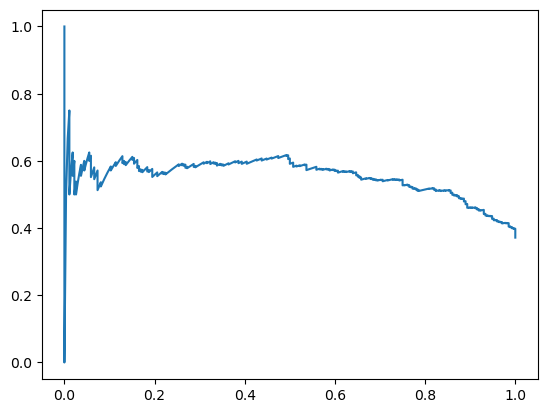

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_recall_curve

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Best params:", search.best_params_)
print(f"Best CV ROC AUC: {search.best_score_:.2f}\n")

print(f"Classification report: \n{classification_report(y_test, y_pred, target_names=['No Error', 'Error'])}")

print(f"Confusion matrix: \n{confusion_matrix(y_test, y_pred)}")

print(f"\nTest ROC AUC: {roc_auc_score(y_test, y_proba):.2f}")
print(f"Test Average Precision: {average_precision_score(y_test, y_proba):.2f}")

precision, recall, threshold = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision, label='Gradient Boosting')